In [89]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'students-performance-dataset' dataset.
Path to dataset files: /kaggle/input/students-performance-dataset


In [90]:
import os
os.listdir(path)

['Student_performance_data _.csv']

In [91]:
import pandas as pd
df = pd.read_csv(path + "/Student_performance_data _.csv")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


# **데이터 확인**

In [92]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [93]:
df.isnull().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


- 결측치 없음
- StudyTimeWeekly 랑 Absences의 값이 범위가 다름 -> 스케일링 필요

In [94]:
# 필요없는 컬럼 제거
df = df.drop(columns=['StudentID'])

# **데이터 분산(EDA) 확인**

In [95]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Ethnicity'}>,
        <Axes: title={'center': 'ParentalEducation'}>],
       [<Axes: title={'center': 'StudyTimeWeekly'}>,
        <Axes: title={'center': 'Absences'}>,
        <Axes: title={'center': 'Tutoring'}>,
        <Axes: title={'center': 'ParentalSupport'}>],
       [<Axes: title={'center': 'Extracurricular'}>,
        <Axes: title={'center': 'Sports'}>,
        <Axes: title={'center': 'Music'}>,
        <Axes: title={'center': 'Volunteering'}>],
       [<Axes: title={'center': 'GPA'}>,
        <Axes: title={'center': 'GradeClass'}>, <Axes: >, <Axes: >]],
      dtype=object)

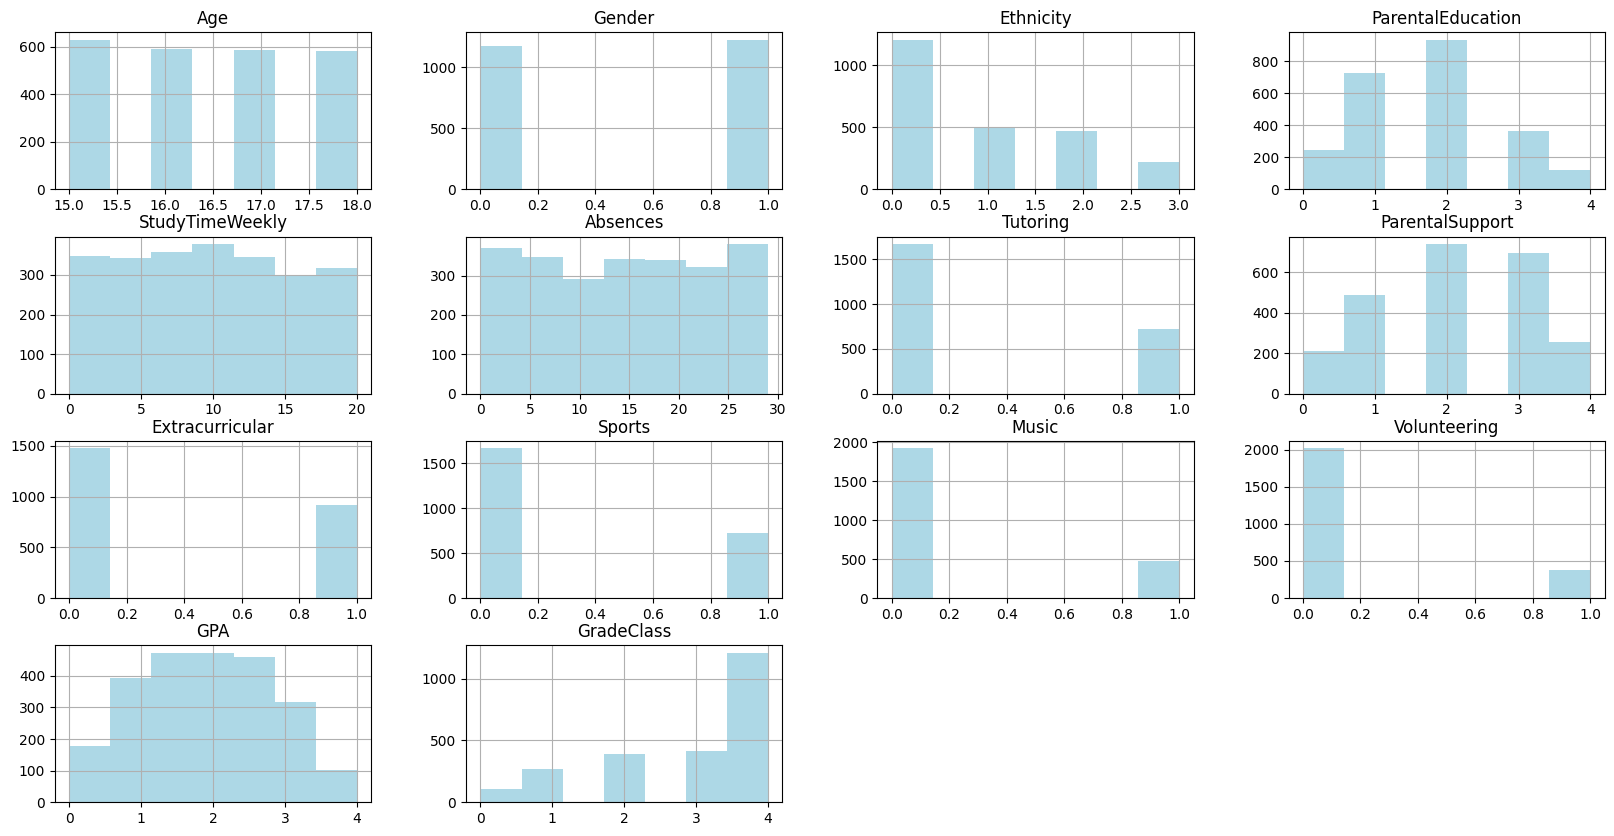

In [96]:
# 데이터 분포 확인
df.hist(figsize=(20,10),bins=7, color='lightblue')

**GPA&GradeClass 분포 확인**

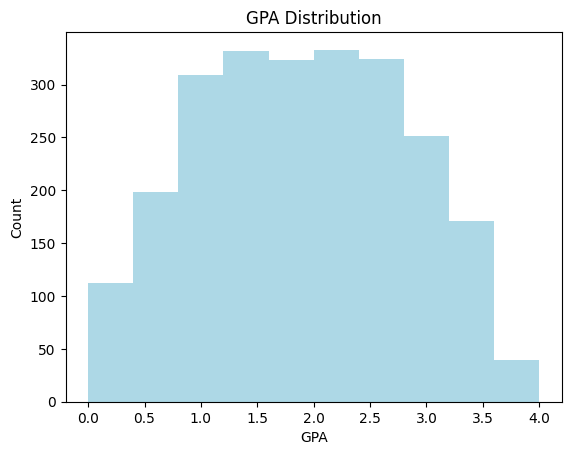

In [97]:
# GPA 분포
plt.hist(df['GPA'], color='lightblue')

plt.title('GPA Distribution')

plt.xlabel('GPA')

plt.ylabel('Count')

plt.show()

<Axes: xlabel='GradeClass'>

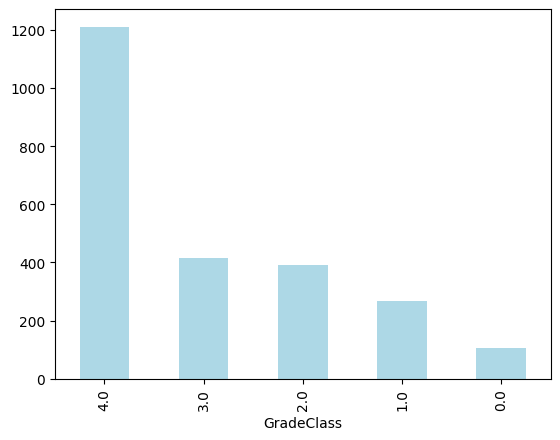

In [98]:
# 타겟(GradeClass) 분포
df["GradeClass"].value_counts().plot(kind="bar",color='lightblue')

불균형 존재!

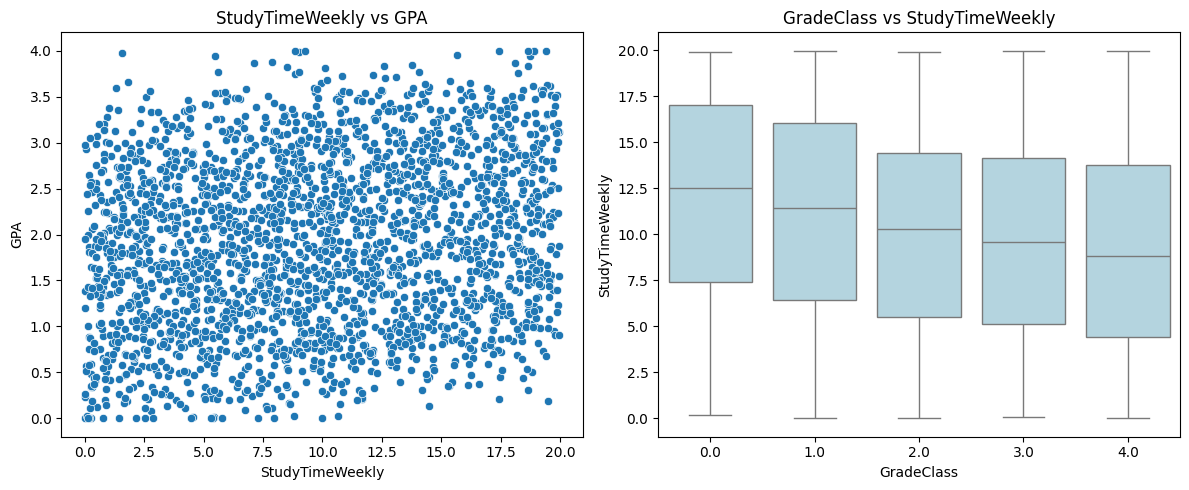

In [99]:
# 공부시간 vs GPA(산점도), GradeClass(박스플랏)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 산점도
sns.scatterplot(x='StudyTimeWeekly', y='GPA', data=df, ax=axes[0])
axes[0].set_title('StudyTimeWeekly vs GPA')

# 박스플랏
sns.boxplot(data=df, x="GradeClass", y="StudyTimeWeekly", color='lightblue', ax=axes[1])
axes[1].set_title('GradeClass vs StudyTimeWeekly')

plt.tight_layout()
plt.show()

**가설1 "공부시간이 많을수록 성적이 높을 것이다"**

[scatter]
- 점들이 넓게 퍼져있어 뚜렷한 선형 관계는 확인하기 어렵다.
- 공부시간이 증가함에 따라 GPA가 증가하는 추세가 보여 약한 양의 상관관계라 할 수 있다.

[boxplot]
- GradeClass가 0(A)에서 4(F)로 갈수록 StudyTimeWeekly의 중앙값이 약 12.5 → 9.5로 점진적으로 감소하는 추세를 보인다.
- 단, 등급 간 박스 범위가 많이 겹쳐있어 공부시간만으로 성적을 완전히 설명하기는 어렵다.

→ 가설 채택, 단 영향력은 제한적

Text(0.5, 1.0, 'GradeClass vs Absences')

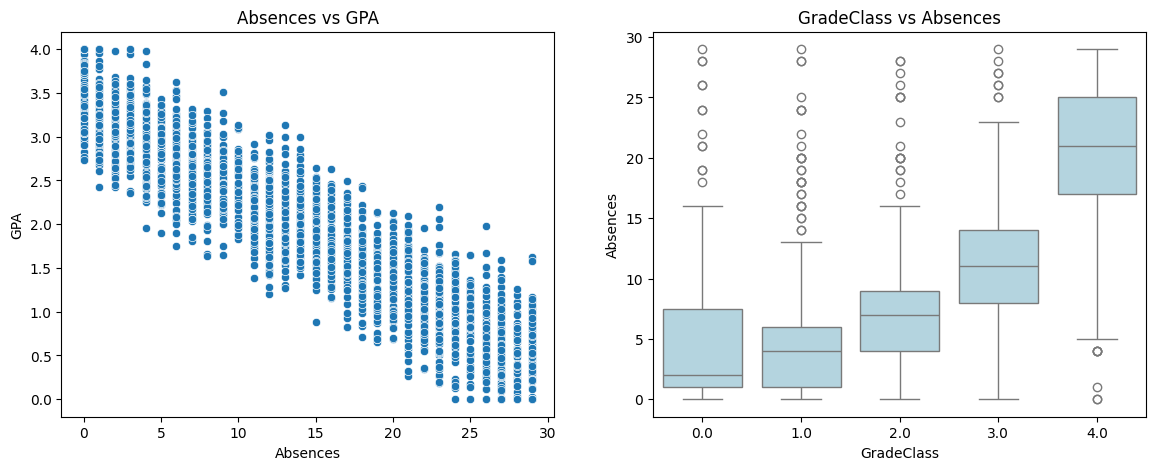

In [100]:
# 결석 vs GAP(산점도), GradeClass(박스플랏)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='Absences', y='GPA', data=df, ax=axes[0])
axes[0].set_title('Absences vs GPA')

sns.boxplot(data=df, x="GradeClass", y="Absences", color="lightblue", ax=axes[1])
axes[1].set_title('GradeClass vs Absences')

**가설2 "결석이 많을수록 성적이 낮을 것이다."**

[scatter]
- Absences가 증가함에 따라 GPA가 감소함을 확인할 수 있다.
- 산점도가 모여 있어 강한 음의 상관관계임을 알 수 있다.

[boxplot]
- GradeClass가 0(A)에서 4(F)로 갈수록 Absences 중앙값이 약 2 → 21로 급격히 증가한다.
- 등급 간 박스 범위도 뚜렷하게 분리되어 있다.

→ 가설 채택, 가장 강력한 영향 변수

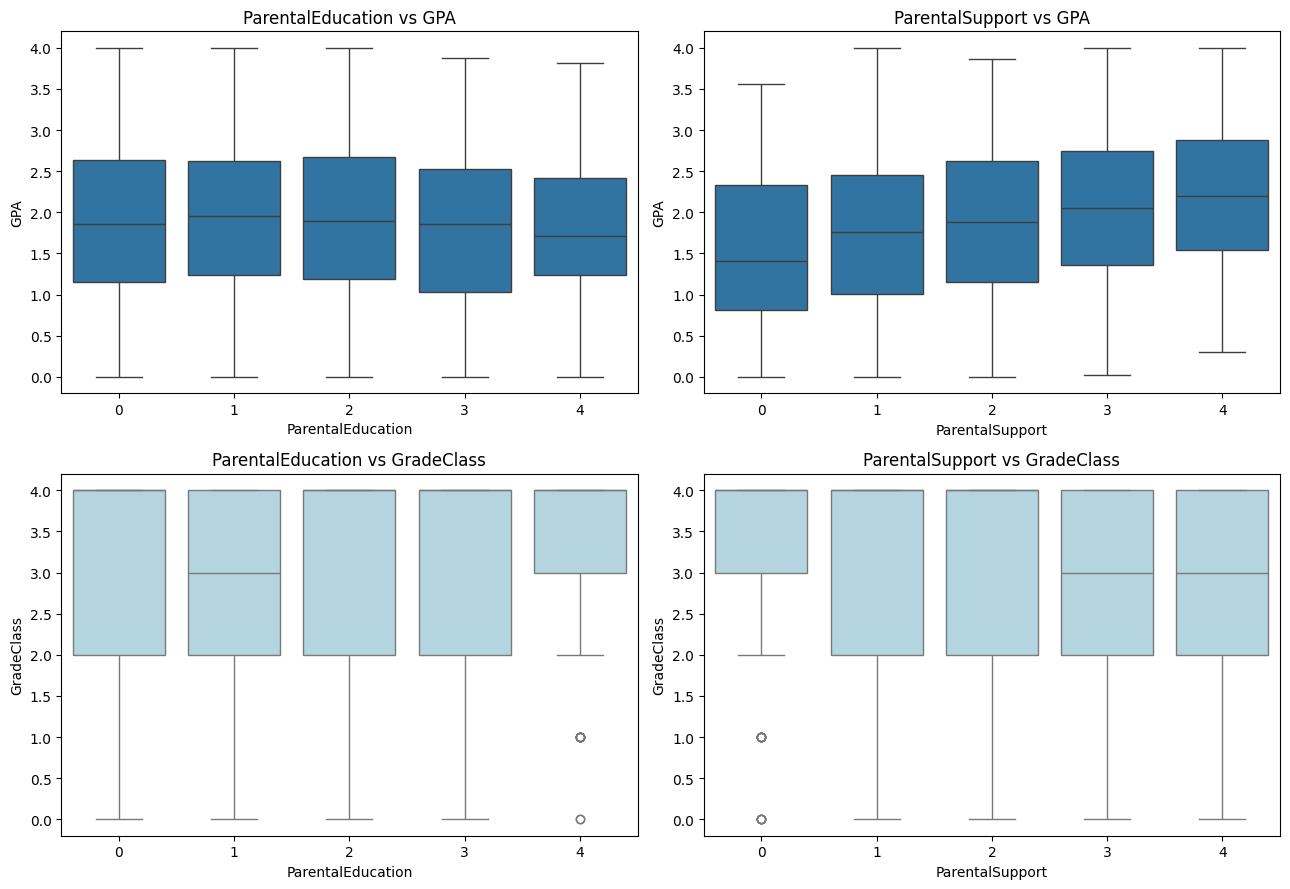

In [101]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

cols = ["ParentalEducation", "ParentalSupport"]

# 윗줄: GPA
for i, col in enumerate(cols):
    sns.boxplot(x=df[col], y=df['GPA'],  ax=axes[0][i])
    axes[0][i].set_title(f'{col} vs GPA')

# 아랫줄: GradeClass
for i, col in enumerate(cols):
    sns.boxplot(data=df, x=col, y="GradeClass", color="lightblue", ax=axes[1][i])
    axes[1][i].set_title(f'{col} vs GradeClass')

plt.tight_layout()
plt.show()

**가설 3 "부모 교육수준이 성적에 영향을 준다"**

[GPA 기준]
- ParentalEducation: 모든 단계에서 GPA 중앙값이 거의 동일
- ParentalSupport: 지원 수준이 높아질수록 GPA가 미세하게 증가하는 경향이 보이나 박스 범위가 많이 겹쳐 있어 뚜렷한 차이라 보기 어려움

[GradeClass 기준]
- 모든 그룹에서 박스가 0~4 전체에 걸쳐 고르게 분포
- 그룹 간 중앙값 차이가 거의 없음

→ 가설 기각

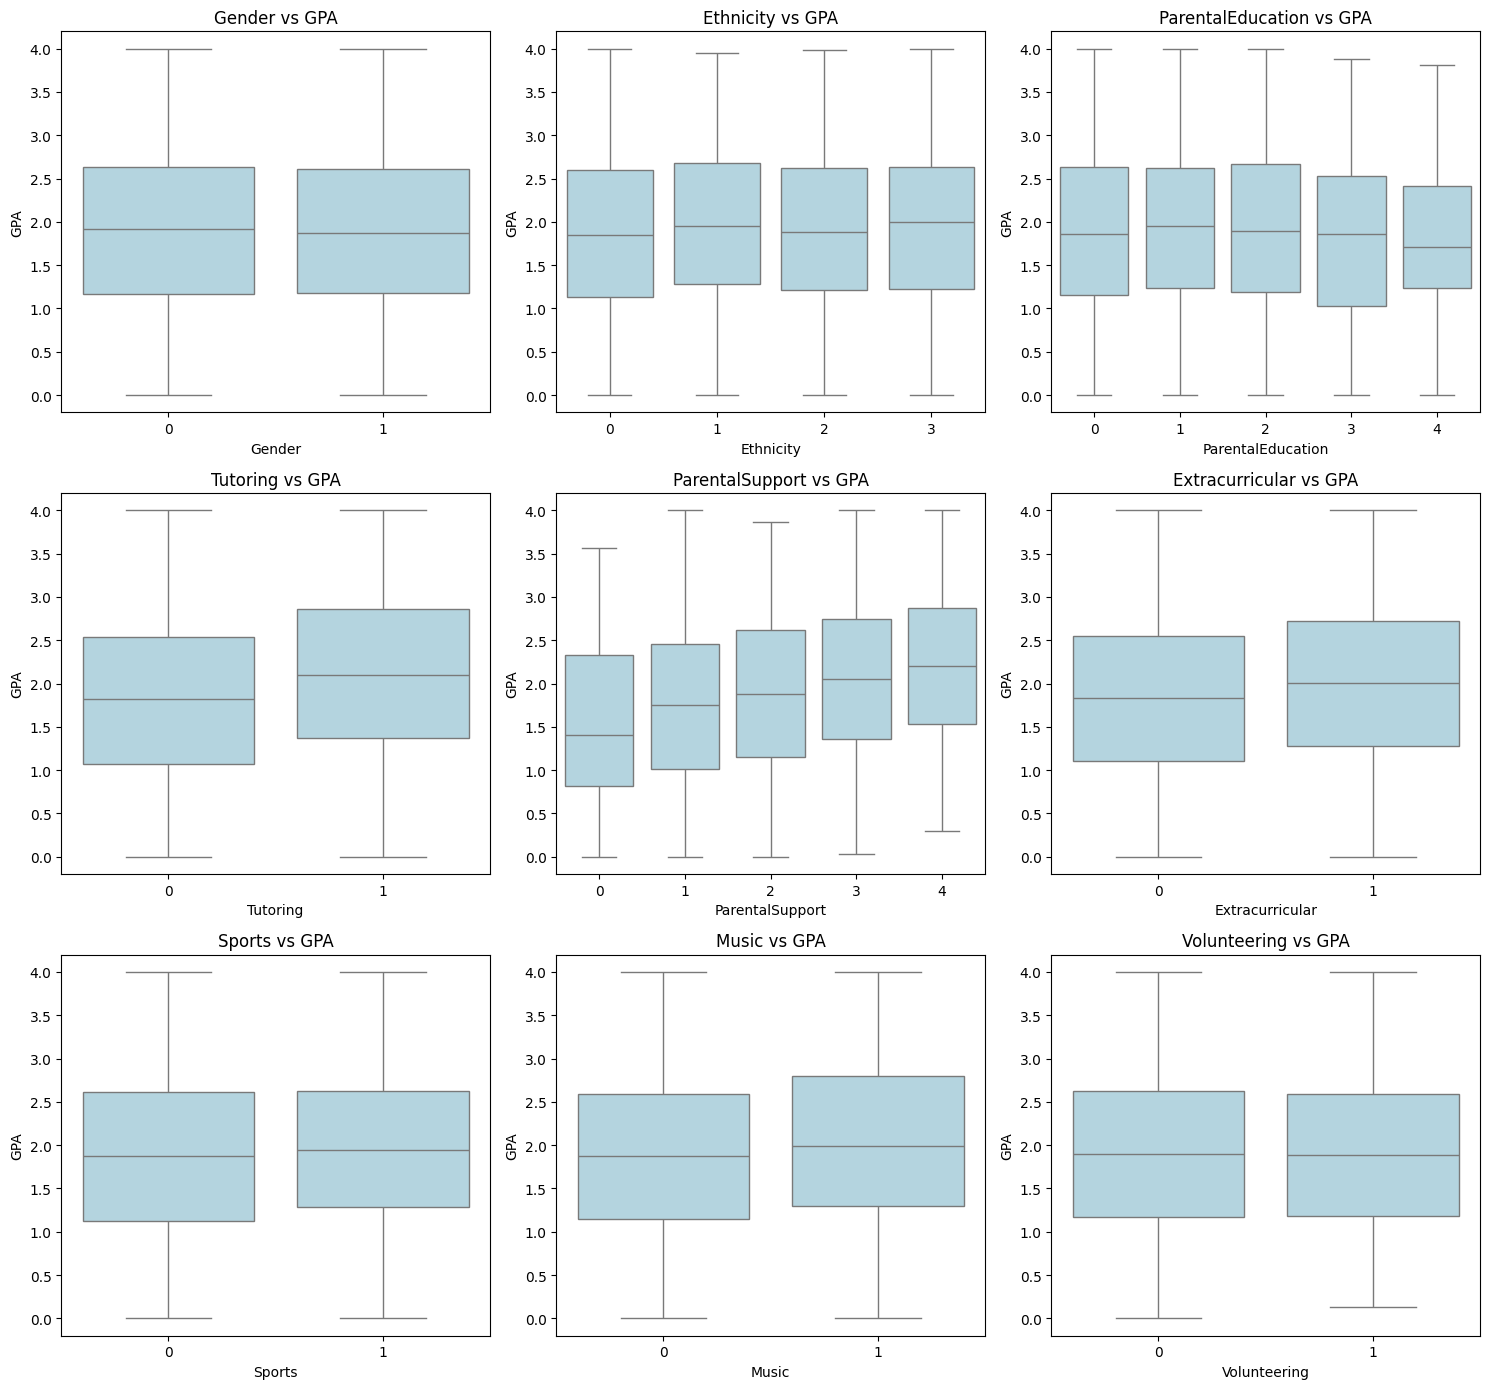

In [102]:
# boxplot으로 볼 범주형 변수들
cols = [
    'Gender',
    'Ethnicity',
    'ParentalEducation',
    'Tutoring',
    'ParentalSupport',
    'Extracurricular',
    'Sports',
    'Music',
    'Volunteering'
]

# 그래프 틀 생성
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 14))

axes = axes.flatten()

# boxplot 생성
for i, col in enumerate(cols):

    sns.boxplot(
        x=df[col],
        y=df['GPA'],
        ax=axes[i],
        color="lightblue"
    )

    axes[i].set_title(f'{col} vs GPA')

# 레이아웃 정리
plt.tight_layout()

# 출력
plt.show()

*   튜터링을 받는 학생들이 받지 않는 학생들보다 GPA 중앙값이 다소 높게 나타났다.
*   부모지원수준이 높을수록 GPA 분포와 중앙값이 전반적으로 상승하는 경향을 보였다.
*   비교과 활동에 참여하는 학생들이 평균적으로 더 높은 GPA 분포를 보였다.
*   스포츠, 음악, 봉사활동 여부에 따른 GPA 차이는 존재하지만, 다른 변수들에 비해 영향은 상대적으로 크지 않은 것으로 보인다.
*  일부 변수는 그룹 간 GPA 차이가 크지 않아 성적에 미치는 영향력이 제한적일 가능성이 있다.




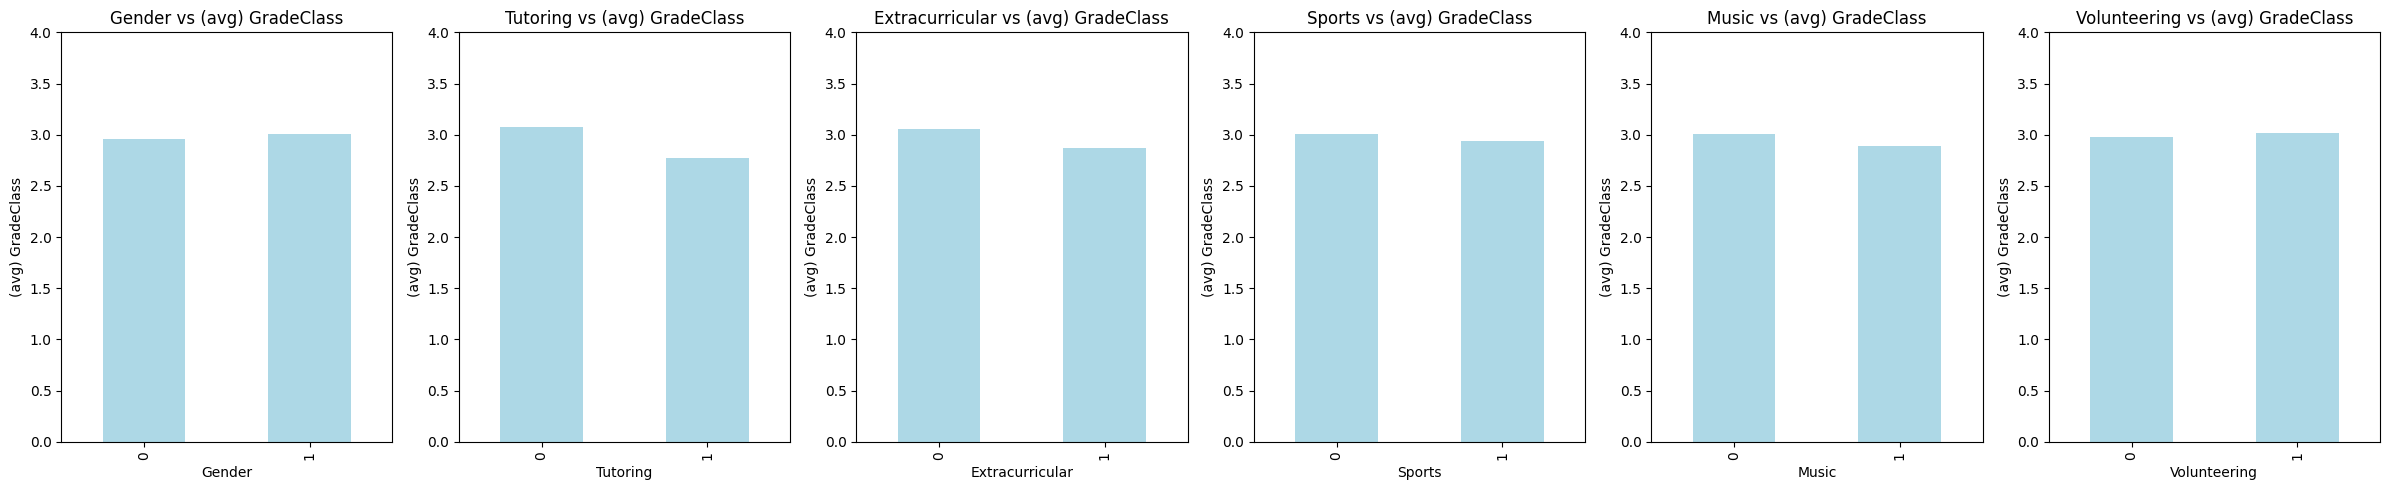

In [103]:
# 변수별 평균 성적 분석
binary_cols = ["Gender", "Tutoring", "Extracurricular", "Sports", "Music", "Volunteering"]

fig, axes = plt.subplots(1, 6, figsize=(24, 5))

for ax, col in zip(axes, binary_cols):
    df.groupby(col)["GradeClass"].mean().plot(kind="bar", ax=ax, color="lightblue")
    ax.set_title(f"{col} vs (avg) GradeClass")
    ax.set_ylim(0, 4)
    ax.set_xlabel(col)
    ax.set_ylabel("(avg) GradeClass")

plt.tight_layout()
plt.show()

- 대부분의 이진 변수는 평균 GradeClass에 거의 영향을 주지 않음
- Tutoring과 Extracurricular에서 미세한 차이가 있으나 막대 높이 차이가 0.2~0.3 수준으로 의미있는 차이라 보기 어려움

→ 이진 변수 단독으로는 성적에 뚜렷한 영향을 주지 않음

<Axes: >

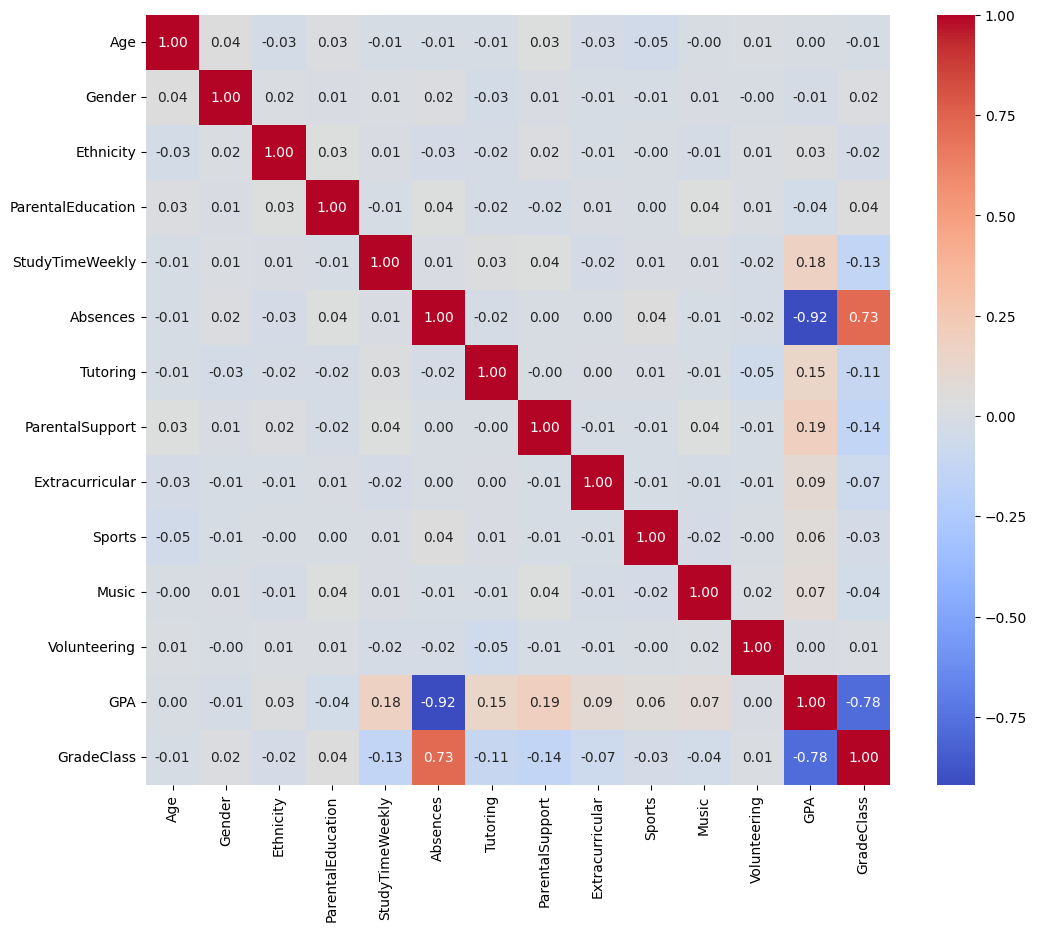

In [104]:
# 상관관계 히트맵
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")

**[기준]**
*   0.0 ~ 0.1 : 거의 없음
*   0.1 ~ 0.3 : 약한 상관관계
*   0.3 ~ 0.5 : 중간 상관관계
*   0.5 이상 : 강한 상관관계


1. GradeClass - Absences 상관계수 0.73으로 가장 강한 양의 상관관계, 결석이 많을수록 낮은 성적(F)에 가까워짐을 확인

2. Absences 제외 시 StudyTimeWeekly -0.13, Tutoring -0.11, ParentalSupport -0.14로 모두 0.15 이하의 약한 상관관계

3. 결석과 GPA 사이의 관계가 가장 강력(-0.92)하며, 결석이 성적 전반에 핵심 변수임을 뒷받침한다
    
    단, GPA는 GradeClass의 파생변수이므로 모델 학습에서 제외하였으며, Absences-GPA(-0.92)는 참고 지표로만 활용

**결석(Absences)이 GradeClass에 가장 강력한 영향(0.73)을 미치며, 나머지 변수들은 단독으로는 성적을 설명하기 어렵다**

# **데이터 전처리**

1. StudentsID 제거 (의미없는 번호라 제거, 이미 진행함)

2. X/Y 분리 (입력값/정답 나누기)

In [105]:
X = df.drop(['GradeClass','GPA'], axis=1)
y = df['GradeClass']

3. train/test 분리

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

4. 스케일링 (숫자 크기 맞추기)

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **모델링**

**1. 로지스틱 회귀**

In [108]:
# 1) 로지스틱 회귀 기본 코드
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Macro F1 Score:", f1)

Accuracy: 0.6826722338204593
Macro F1 Score: 0.4533020501249543


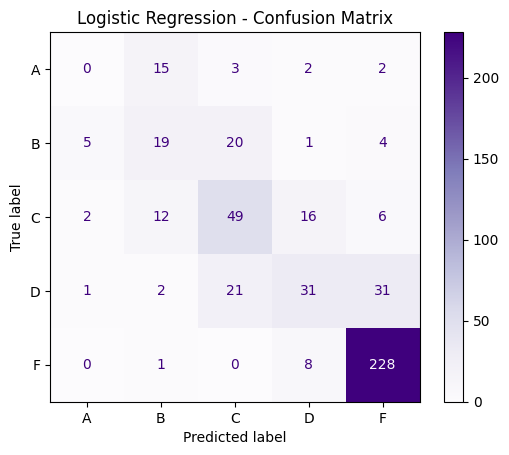

In [109]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_log = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm_log, display_labels=['A','B','C','D','F'])
disp.plot(cmap='Purples')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45843 (\N{HANGUL SYLLABLE DAES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

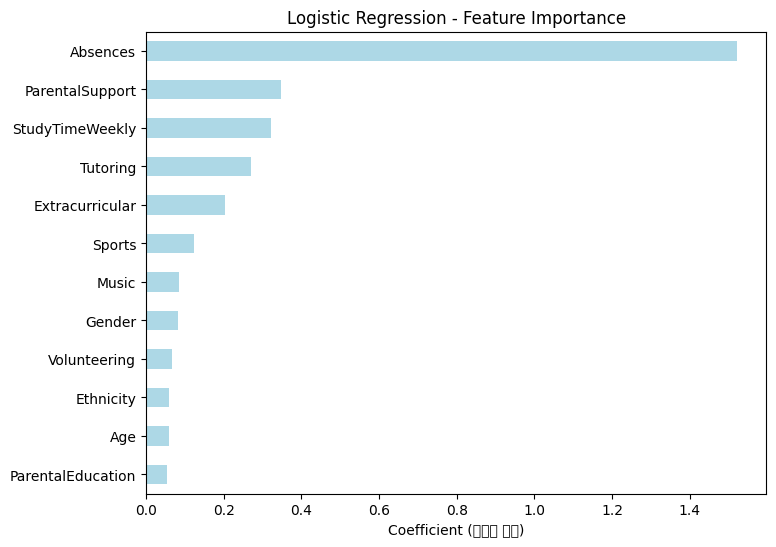

In [110]:
# 로지스틱 회귀 - 변수 중요도
import matplotlib.pyplot as plt
import numpy as np

importance = pd.Series(
    np.abs(lr.coef_).mean(axis=0),
    index=X.columns
).sort_values(ascending=True)

importance.plot(kind='barh', color='lightblue', figsize=(8, 6))
plt.title('Logistic Regression - Feature Importance')
plt.xlabel('Coefficient (절댓값 평균)')
plt.show()

In [111]:
""" 개선사항 3개 """
# 2-1) 클래스 불균형 처리
lr_bal = LogisticRegression(class_weight='balanced')
lr_bal.fit(X_train_scaled, y_train)

y_pred_bal = lr_bal.predict(X_test_scaled)

accuracy_bal = accuracy_score(y_test, y_pred_bal)
f1_bal = f1_score(y_test, y_pred_bal, average='macro')

print("Accuracy (balanced) :", accuracy_bal)
print("Macro F1 Score (balanced) :", f1_bal)

print("")

# 2-2) 수렴 안정화(max_iter 늘리기)
lr_max = LogisticRegression(max_iter=1000)
lr_max.fit(X_train_scaled, y_train)

y_pred_max = lr_max.predict(X_test_scaled)

accuracy_max = accuracy_score(y_test, y_pred_max)
f1_max = f1_score(y_test, y_pred_max, average='macro')

print("Accuracy (max_iter) :", accuracy_max)
print("Macro F1 Score (max_iter) :", f1_max)

print("")

# 2-3) C값 탐색
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1_macro'
)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
y_pred_gs = best_model.predict(X_test_scaled)

print("Accuracy (C) :", accuracy_score(y_test, y_pred_gs))
print("Macro F1 Score (C) :", f1_score(y_test, y_pred_gs, average='macro'))
print("Best C:", grid_search.best_params_)

Accuracy (balanced) : 0.5741127348643006
Macro F1 Score (balanced) : 0.4196090330185047

Accuracy (max_iter) : 0.6826722338204593
Macro F1 Score (max_iter) : 0.4533020501249543

Accuracy (C) : 0.6805845511482255
Macro F1 Score (C) : 0.4499778338405024
Best C: {'C': 100}


**2. 랜덤 포레스트**

랜덤 포레스트 모델 학습

In [112]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))
print("Macro F1 Score :", f1_score(y_test, pred, average='macro'))

Accuracy : 0.6951983298538622
Macro F1 Score : 0.5072801544176022


confusion matrix

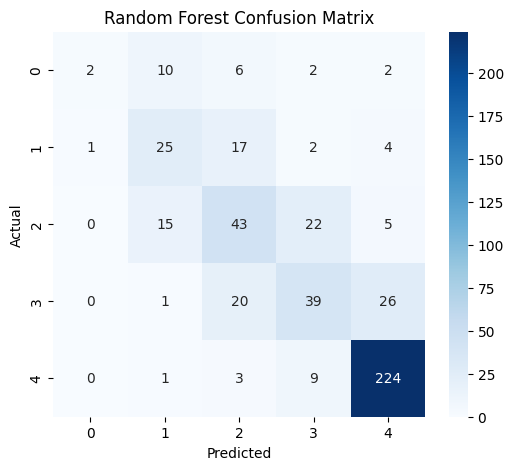

In [113]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest의 분류 성능을 accuracy, F1-score, Confusion Matrix를 통해 평가하였다.

feature importance

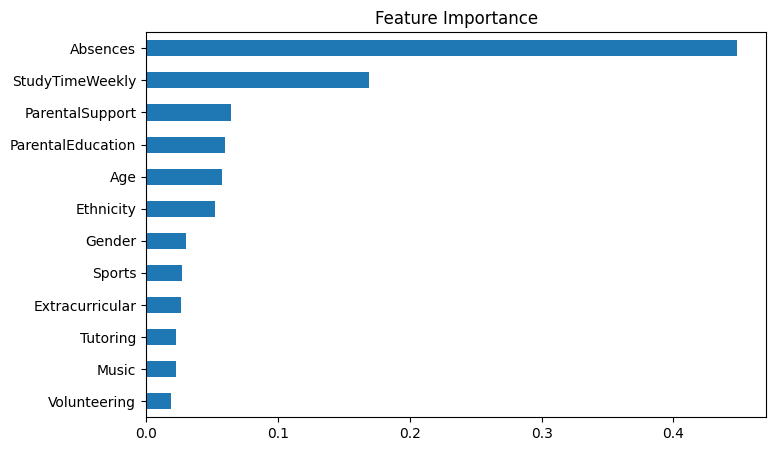

In [114]:
importance = rf.feature_importances_

pd.Series(
    importance,
    index=X_train.columns
).sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Feature Importance')
plt.show()

개선사항 1. 하이퍼파라미터 튜닝

기본 모델

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf_base = RandomForestClassifier(
    random_state=42
)

rf_base.fit(X_train, y_train)

pred_base = rf_base.predict(X_test)

print("Base Accuracy:",
      accuracy_score(y_test, pred_base))

print("Base Macro F1:",
      f1_score(y_test,
               pred_base,
               average='macro'))

Base Accuracy: 0.6951983298538622
Base Macro F1: 0.5072801544176022


개선 모델

In [116]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

pred_tuned = rf_tuned.predict(X_test)

print("Tuned Accuracy:",
      accuracy_score(y_test, pred_tuned))

print("Tuned Macro F1:",
      f1_score(y_test,
               pred_tuned,
               average='macro'))

Tuned Accuracy: 0.6868475991649269
Tuned Macro F1: 0.49698402691911436


결과 비교

In [117]:
import pandas as pd

result = pd.DataFrame({
    "Model":["Basic RF","Tuned RF"],
    "Accuracy":[
        accuracy_score(y_test,pred_base),
        accuracy_score(y_test,pred_tuned)
    ],
    "Macro F1":[
        f1_score(y_test,pred_base,average='macro'),
        f1_score(y_test,pred_tuned,average='macro')
    ]
})

result

,Model,Accuracy,Macro F1
0,Basic RF,0.695198,0.507280
1,Tuned RF,0.686848,0.496984


Random Forest의 성능 향상을 위해 트리 개수(n_estimators)를 증가시키고 최대 깊이(max_depth), 최소 분할 샘플 수(min_samples_split)를 조정하는 하이퍼파라미터 튜닝을 수행하였다.

그러나 실험 결과 Accuracy는 0.6952에서 0.6868로, F1-score는 0.5073에서 0.4970으로 감소하였다.

따라서 현재 데이터셋에서는 기본 Random Forest 모델이 더 적합한 것으로 나타났으며, 하이퍼파라미터 조정이 반드시 성능 향상으로 이어지는 것은 아님을 확인하였다.

개선사항 2. 중요 변수만 사용

Feature Importance에서 나온 상위 변수만 사용. (Absences
StudyTimeWeekly
ParentalSupport
Tutoring
Sports)

In [118]:
top_features = [
    'Absences',
    'StudyTimeWeekly',
    'ParentalSupport',
    'ParentalEducation',
    'Age'
]

In [119]:
X_top = df[top_features]

y = df['GradeClass']

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X_top,
    y,
    test_size=0.2,
    random_state=42
)

In [121]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

print("Macro F1:",
      f1_score(y_test,
               pred,
               average='macro'))

Accuracy: 0.6617954070981211
Macro F1: 0.49872158589166293


상위 중요 변수만 사용한 모델의 성능은 Accuracy 0.6617, F1-score 0.4987로 전체 변수 사용 모델과 큰 차이를 보이지 않았다. 이를 통해 결석 횟수, 공부 시간, 부모 지원 정도 등의 핵심 변수가 학생 성적 예측에 중요한 역할을 함을 확인하였다.

In [122]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

result = pd.DataFrame({
    "Model": [
        # 로지스틱
        "Logistic - 기본",
        "Logistic - balanced",
        "Logistic - max_iter",
        "Logistic - GridSearch",
        # 랜덤포레스트
        "RandomForest - 기본",
        "RandomForest - Tuned",
        "RandomForest - Top Features",
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_bal),
        accuracy_score(y_test, y_pred_max),
        accuracy_score(y_test, y_pred_gs),
        accuracy_score(y_test, pred_base),
        accuracy_score(y_test, pred_tuned),
        accuracy_score(y_test, pred),
    ],
    "Macro F1": [
        f1_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred_bal, average='macro'),
        f1_score(y_test, y_pred_max, average='macro'),
        f1_score(y_test, y_pred_gs, average='macro'),
        f1_score(y_test, pred_base, average='macro'),
        f1_score(y_test, pred_tuned, average='macro'),
        f1_score(y_test, pred, average='macro'),
    ]
})

# 소수점 4자리로 정리
result["Accuracy"] = result["Accuracy"].round(4)
result["Macro F1"] = result["Macro F1"].round(4)

# Macro F1 기준 내림차순 정렬
result = result.sort_values("Macro F1", ascending=False).reset_index(drop=True)

result

,Model,Accuracy,Macro F1
0,RandomForest - 기본,0.6952,0.5073
1,RandomForest - Top Features,0.6618,0.4987
2,RandomForest - Tuned,0.6868,0.4970
3,Logistic - 기본,0.6827,0.4533
4,Logistic - max_iter,0.6827,0.4533
5,Logistic - GridSearch,0.6806,0.4500
6,Logistic - balanced,0.5741,0.4196


**3. K-MEANS**

In [123]:
#K-means 훈련
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import accuracy_score, f1_score

kmeans = KMeans(n_clusters=5, random_state=42)
train_cluster_labels = kmeans.fit_predict(X_train_scaled)

# K-means 클러스터 번호와 실제 성적 등급 매핑하기
# 각 클러스터(0~4)에 모인 학생들의 실제 y_train 값 중
# 최빈값을 기준으로 삼습니다.
cluster_to_grade_map = {}
for i in range(5):
    mask = (train_cluster_labels == i)
    if np.sum(mask) > 0:
        # 각 군집 내부의 최빈값을 찾아 매핑 딕셔너리에 저장
        cluster_to_grade_map[i] = mode(y_train.values[mask], keepdims=True)[0][0]

# 예측 후, 매핑 기준에 따라 실제 Grade Class으로 변환
test_cluster_labels = kmeans.predict(X_test_scaled)
y_pred_k = np.array([cluster_to_grade_map[c] for c in test_cluster_labels])

accuracy = accuracy_score(y_test, y_pred_k)
f1 = f1_score(y_test, y_pred_k, average='macro')

print("Accuracy:", accuracy)
print("Macro F1 Score:", f1)

Accuracy: 0.49478079331941544
Macro F1 Score: 0.1324022346368715


개선사항1 - 노이즈 제거

> PCA (차원 축소)





In [124]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state = 42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(X_train_pca.shape)


(1913, 2)


개선사항2- 클러스터 개수 변경


> 엘보우방법




<function matplotlib.pyplot.show(close=None, block=None)>

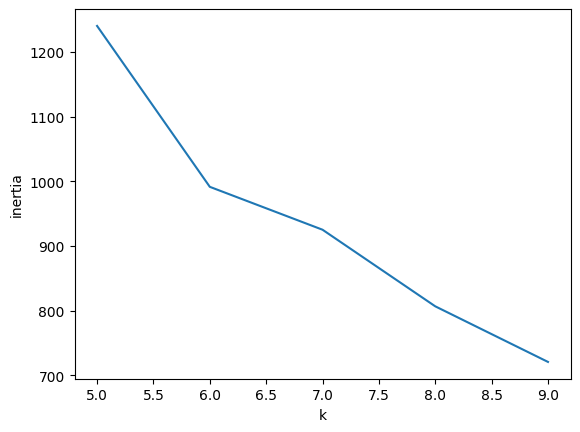

In [125]:
inertia = []
for k in range(5,10):
  km = KMeans(n_clusters=k,random_state=42)
  km.fit(X_train_pca)
  inertia.append(km.inertia_)
plt.plot(range(5,10),inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.show



*   6이 최적의 클러스터 개수라고 예측할 수 있다



개선사항3 - 클러스터 개수 변경


> 실루엣 점수



In [126]:
from sklearn.metrics import silhouette_score

for k in range(5, 30):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_train_pca)

    score = silhouette_score(X_train_pca, labels)
    print(f"Clusters: {k} | Silhouette Score: {score:.4f}")

Clusters: 5 | Silhouette Score: 0.3201
Clusters: 6 | Silhouette Score: 0.3425
Clusters: 7 | Silhouette Score: 0.3307
Clusters: 8 | Silhouette Score: 0.3257
Clusters: 9 | Silhouette Score: 0.3156
Clusters: 10 | Silhouette Score: 0.3238
Clusters: 11 | Silhouette Score: 0.3211
Clusters: 12 | Silhouette Score: 0.3264
Clusters: 13 | Silhouette Score: 0.3243
Clusters: 14 | Silhouette Score: 0.3193
Clusters: 15 | Silhouette Score: 0.3317
Clusters: 16 | Silhouette Score: 0.3326
Clusters: 17 | Silhouette Score: 0.3222
Clusters: 18 | Silhouette Score: 0.3233
Clusters: 19 | Silhouette Score: 0.3262
Clusters: 20 | Silhouette Score: 0.3275
Clusters: 21 | Silhouette Score: 0.3280
Clusters: 22 | Silhouette Score: 0.3218
Clusters: 23 | Silhouette Score: 0.3280
Clusters: 24 | Silhouette Score: 0.3291
Clusters: 25 | Silhouette Score: 0.3386
Clusters: 26 | Silhouette Score: 0.3282
Clusters: 27 | Silhouette Score: 0.3352
Clusters: 28 | Silhouette Score: 0.3365
Clusters: 29 | Silhouette Score: 0.3387


실루엣 점수도 K가 6일 때 가장 크다.
따라서, 클러스터의 값이 6일때 가장 점수가 높다.

In [127]:
kmeans = KMeans(n_clusters=6, random_state=42)
train_cluster_labels = kmeans.fit_predict(X_train_pca)

cluster_to_grade_map = {}
for i in range(6):
    mask = (train_cluster_labels == i)
    if np.sum(mask) > 0:
        # 각 군집 내부의 최빈값을 찾아 매핑 딕셔너리에 저장
        cluster_to_grade_map[i] = mode(y_train.values[mask], keepdims=True)[0][0]

# 예측 후, 매핑 기준에 따라 실제 Grade Class으로 변환
test_cluster_labels = kmeans.predict(X_test_pca)
y_pred_k = np.array([cluster_to_grade_map[c] for c in test_cluster_labels])

accuracy = accuracy_score(y_test, y_pred_k)
f1 = f1_score(y_test, y_pred_k, average='macro')

print("Accuracy:", accuracy)
print("Macro F1 Score:", f1)

Accuracy: 0.49478079331941544
Macro F1 Score: 0.1324022346368715


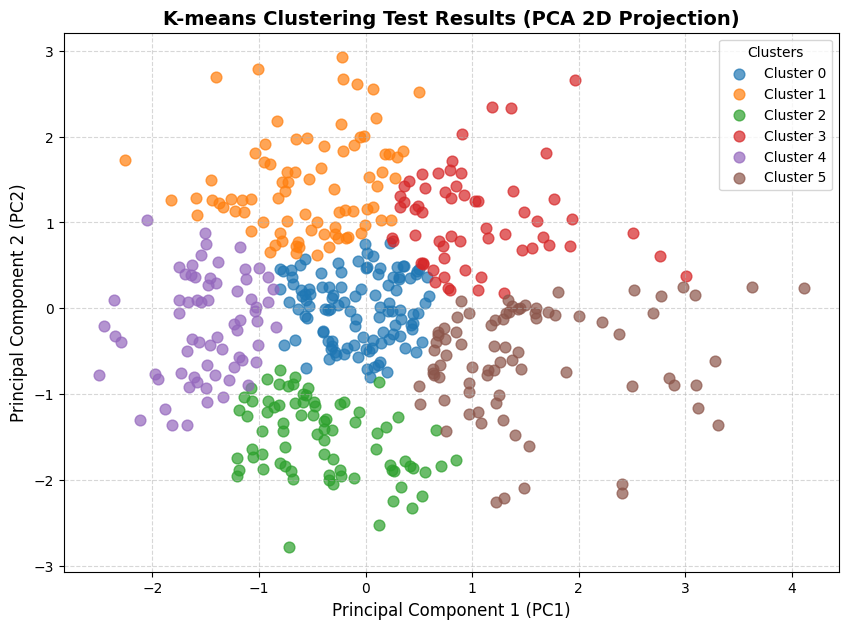

In [128]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)


test_cluster_labels = kmeans.predict(X_test_pca)

plt.figure(figsize=(10, 7))


for label in range(6):
    mask = (test_cluster_labels == label)
    if np.sum(mask) > 0:
        plt.scatter(
            X_test_pca[mask, 0],
            X_test_pca[mask, 1],
            label=f'Cluster {label}',
            alpha=0.7,
            s=60
        )

plt.title('K-means Clustering Test Results (PCA 2D Projection)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(title="Clusters", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 등급 예측

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 4개 핵심 변수만 사용한 예측 모델
top_features = ['StudyTimeWeekly', 'Absences', 'ParentalSupport', 'Tutoring']
X_top4 = df[top_features]
y_top4 = df['GradeClass']

# 1) 검증용
X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_top4, y_top4, test_size=0.2, random_state=42
)

rf_eval = RandomForestClassifier(random_state=42)
rf_eval.fit(X_train4, y_train4)
pred4 = rf_eval.predict(X_test4)

print("4개 변수 모델 성능 (검증용)")
print("Accuracy:", accuracy_score(y_test4, pred4))
print("Macro F1:", f1_score(y_test4, pred4, average='macro'))

# 2) 서비스용: 검증 끝났으니 전체 데이터로 재학습 (실제 예측에 사용)
rf_top4 = RandomForestClassifier(random_state=42)
rf_top4.fit(X_top4, y_top4)

4개 변수 모델 성능 (검증용)
Accuracy: 0.6680584551148225
Macro F1: 0.5325617169497685


RandomForestClassifier(random_state=42)

In [130]:
grade_labels = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}

def predict_my_grade(study_time, absences, parental_support, tutoring):
    my_data = pd.DataFrame(
        [[study_time, absences, parental_support, tutoring]],
        columns = top_features
    )
    pred = rf_top4.predict(my_data)[0]
    proba = rf_top4.predict_proba(my_data)[0]

    print(f"예측 등급: {grade_labels[pred]}")
    print("등급별 확률:")
    for i, p in enumerate(proba):
        print(f"  {grade_labels[i]}: {p*100:.1f}%")

    return pred

In [131]:
def compare_with_A_group(study_time, absences, parental_support, tutoring):
    a_group = df[df['GradeClass'] == 0]
    a_avg = a_group[top_features].mean()
    my_values = [study_time, absences, parental_support, tutoring]

    print(f"{'항목':<18}{'A등급 평균':>12}{'내 값':>10}{'차이':>10}")
    print("-" * 65)
    for feat, my_val in zip(top_features, my_values):
        avg_val = a_avg[feat]
        diff = my_val - avg_val
        print(f"{feat:<18}{avg_val:>14.2f}{my_val:>15.2f}{diff:>+15.2f}")

In [132]:
# 등급 예측 모델
def get_user_input():
    print("=== 정보를 입력해주세요 ===")
    study_time = float(input("주간 공부시간(시간, 0~20): "))
    absences = int(input("결석 횟수(0~30): "))
    parental_support = int(input("부모지원 수준(0=없음 ~ 4=매우높음): "))
    tutoring = int(input("튜터링 여부(0=아니오, 1=예): "))
    return study_time, absences, parental_support, tutoring

def full_report_interactive():
    study_time, absences, parental_support, tutoring = get_user_input()
    print("\n===== 등급 예측 =====")
    predict_my_grade(study_time, absences, parental_support, tutoring)
    print("\n===== A등급 학생과 비교 =====")
    compare_with_A_group(study_time, absences, parental_support, tutoring)

full_report_interactive()

=== 정보를 입력해주세요 ===
주간 공부시간(시간, 0~20): 10
결석 횟수(0~30): 8
부모지원 수준(0=없음 ~ 4=매우높음): 2
튜터링 여부(0=아니오, 1=예): 1

===== 등급 예측 =====
예측 등급: B
등급별 확률:
  A: 1.0%
  B: 44.0%
  C: 41.0%
  D: 11.0%
  F: 3.0%

===== A등급 학생과 비교 =====
항목                      A등급 평균       내 값        차이
-----------------------------------------------------------------
StudyTimeWeekly            11.85          10.00          -1.85
Absences                    5.75           8.00          +2.25
ParentalSupport             2.68           2.00          -0.68
Tutoring                    0.49           1.00          +0.51
